## 분석 주제
**배송 지연 예측 기반 고객 만족도 관리 시스템**

## 주요 질문
**"배송 서비스 품질을 높여서 고객 만족도 관리를 할 수 있을까?"**


In [498]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency                                                                                                                     

import scikit_posthocs as sp

from unidecode import unidecode
import geopandas as gpd
import sys
import os

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # 모든 컬럼이 다 보인다.
pd.set_option('display.max_rows', 100) # 행 출력 개수 제한

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [499]:
# 데이터 로드 & 정제

all = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
df= all.copy()
# print(df.shape[0], 'rows × ', df.shape[1], 'columns')
# 111495 rows ×  29 columns

# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]
# removed rows: 1881
# remaining rows: 10961

In [500]:
# 배송 지연 계산 (핵심 타겟)
# 배송 지연 일수 계산
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

# is_delayed가 양수면 배송 지연된것. 음수면 조기 배송

In [501]:
# 필요한 컬럼만 뽑아보자
product_column = ['product_id', 'product_category_name_english','product_weight_g',
                  'product_length_cm','product_height_cm','product_width_cm',
                  'delivery_delay_days','is_delayed']

df_product = df[product_column].copy()

# 조기배송은 0으로 통일, 지연배송은 그대로
df_product['actual_delay_days'] = np.where(df_product['delivery_delay_days'] < 0 , 0, df_product['delivery_delay_days'])


# 가설 설정
### 무게/부피
- 귀무가설 : "크기/무게는 배송 속도와 무관하다."
- 대립가설 : "크고 무거울수록 배송이 더 늦어진다."

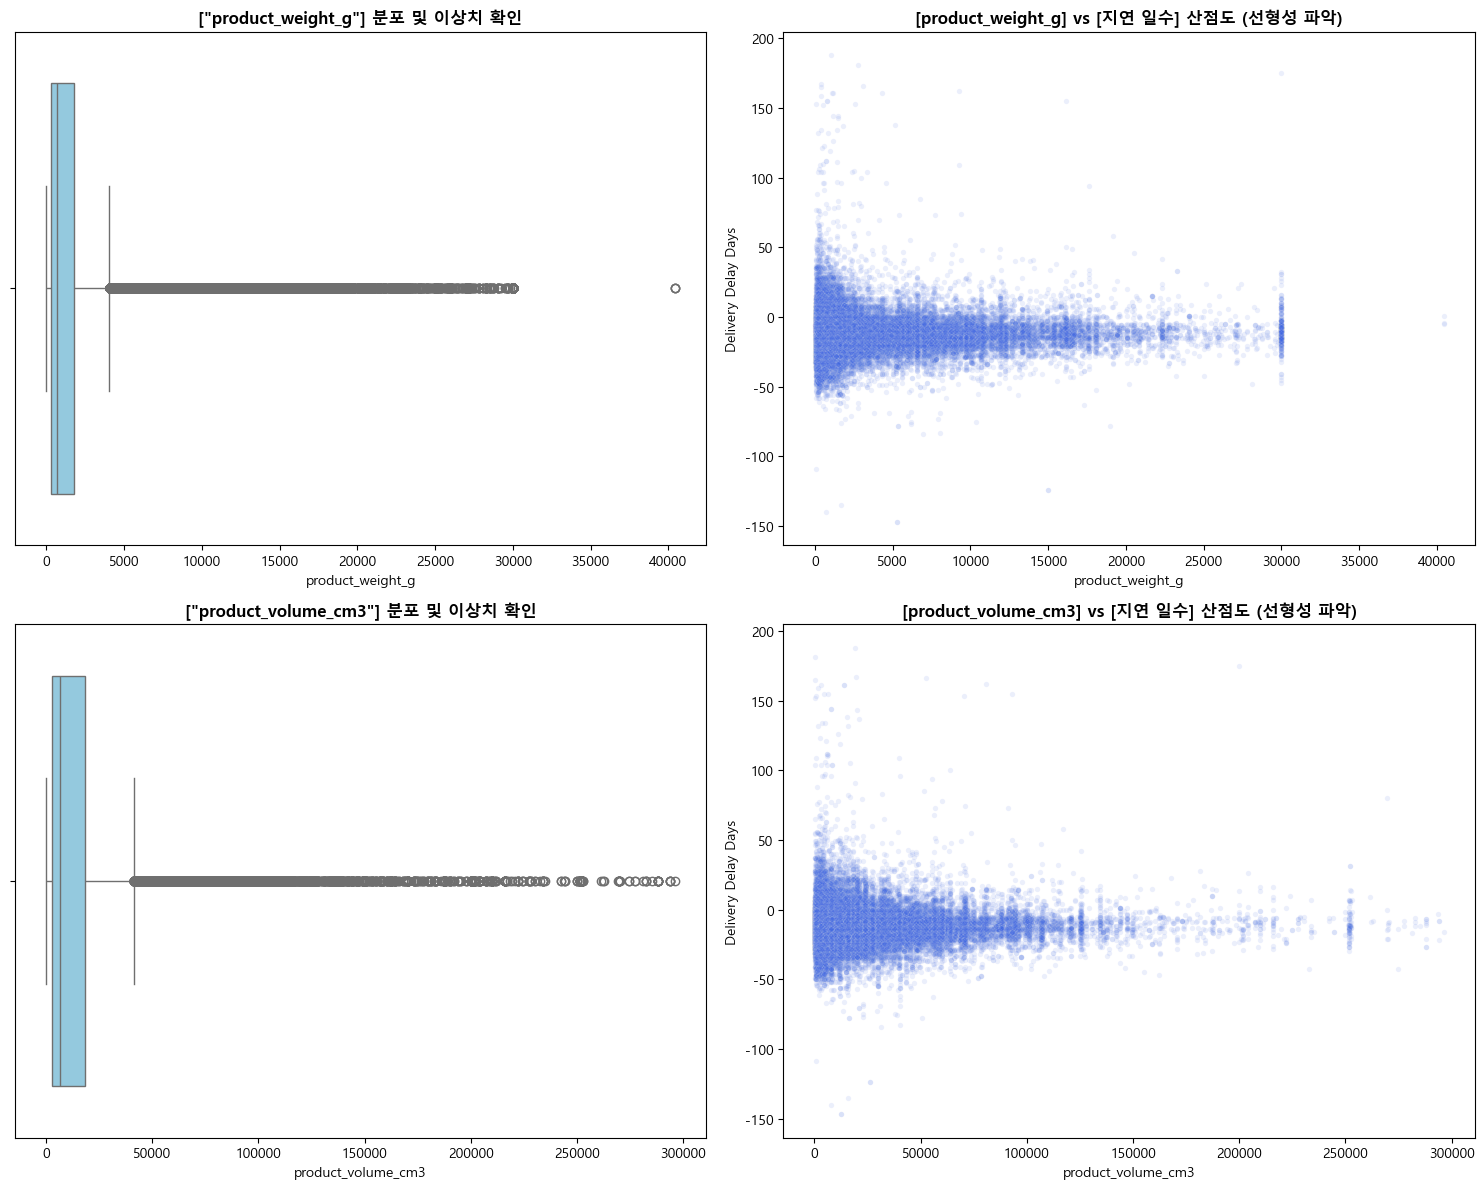

In [502]:
# 결측치 대체/제거
df_product['product_category_name_english'] = df_product['product_category_name_english'].fillna('unknown')
df_product = df_product.dropna(subset=[
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
])

# product_volume_cm3 파생변수 생성
# 부피 = 길이 X 높이 X 너비
df_product['product_volume_cm3'] = df_product['product_length_cm'] * df_product['product_height_cm'] * df_product['product_width_cm']

# 박스플롯
target = 'delivery_delay_days'
compare_cols = ['product_weight_g', 'product_volume_cm3']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
for i, col in enumerate(compare_cols):
    sns.boxplot(x=df_product[col], ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'["{col}"] 분포 및 이상치 확인', fontweight='bold')

    sns.scatterplot(
        x=df_product[col], 
        y=df_product['delivery_delay_days'], 
        ax=axes[i, 1], 
        color='royalblue',
        alpha=0.1,  
        s=15        # 점 크기 줄임
    )
    axes[i, 1].set_title(f'[{col}] vs [지연 일수] 산점도 (선형성 파악)', fontweight='bold', fontsize=12)
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Delivery Delay Days')

plt.tight_layout()
plt.show()

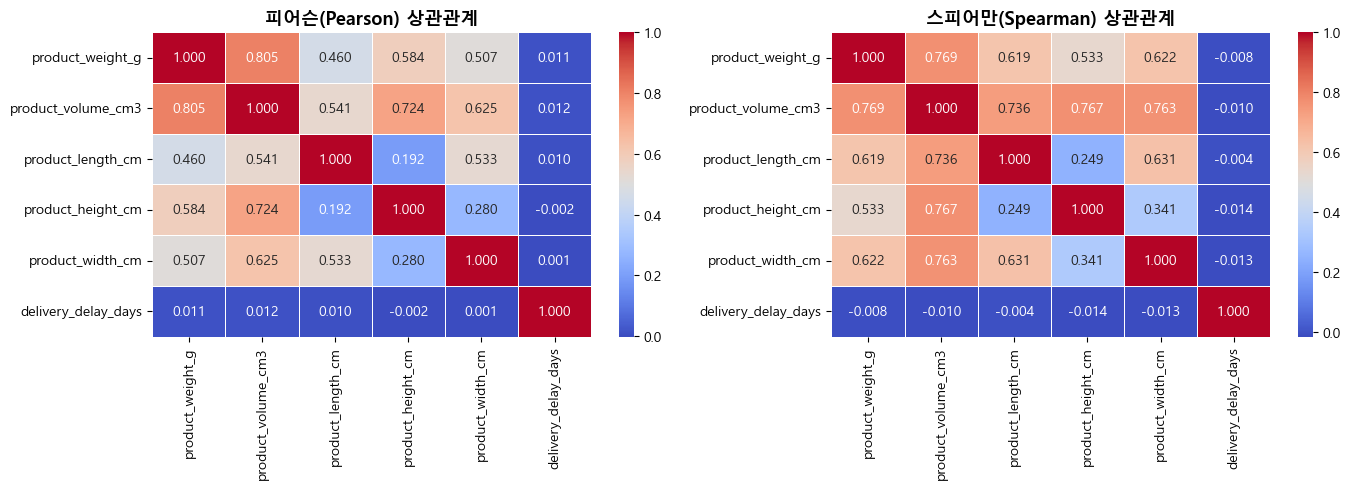

[상관관계 통계적 유의성 검정 (Pearson & Spearman)]
------------------------------------------------------------

분석 대상: [product_weight_g] vs [delivery_delay_days]

피어슨 r: 0.0113 (p-value: 1.7898e-04)
통계적으로는 유의미하나 계수가 0.1 미만이라. 영향력이 없다(상관없음).

스피어만 ρ: -0.0079 (p-value: 8.5976e-03)
통계적으로는 유의미하나 계수가 0.1 미만이라. 영향력이 없다(상관없음).
------------------------------------------------------------

분석 대상: [product_volume_cm3] vs [delivery_delay_days]

피어슨 r: 0.0121 (p-value: 6.2518e-05)
통계적으로는 유의미하나 계수가 0.1 미만이라. 영향력이 없다(상관없음).

스피어만 ρ: -0.0104 (p-value: 5.4533e-04)
통계적으로는 유의미하나 계수가 0.1 미만이라. 영향력이 없다(상관없음).


In [503]:
# 분석할 최종 컬럼 리스트 업데이트
features = ['product_weight_g', 'product_volume_cm3', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'delivery_delay_days']
corr_data = df_product[features]

# 상관계수 계산 (Pearson & Spearman)
corr_pearson = corr_data.corr(method='pearson')
corr_spearman = corr_data.corr(method='spearman')

# 히트맵 시각화
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# 왼쪽: 피어슨 히트맵
sns.heatmap(
    corr_pearson, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, ax=axes[0]
)
axes[0].set_title('피어슨(Pearson) 상관관계', fontsize=13, fontweight='bold')

# 오른쪽: 스피어만 히트맵
sns.heatmap(
    corr_spearman, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, ax=axes[1]
)
axes[1].set_title('스피어만(Spearman) 상관관계', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

def analyze(coef, p_val):
    if p_val >= 0.05:
        return "p-value가 0.05 이상이므로 통계적으로 무의미하다.(상관관계 없음)"
    
    abs_coef = abs(coef)
    direction = "양(+)" if coef > 0 else "음(-)"
    
    if abs_coef < 0.1:
        return "통계적으로는 유의미하나 계수가 0.1 미만이라. 영향력이 없다(상관없음)."
    elif abs_coef < 0.3:
        return f"{direction}의 방향의 약한 상관관계가 존재한다."
    elif abs_coef < 0.7:
        return f"{direction}의 방향의 뚜렷한 상관관계가 존재한다."
    else:
        return f"{direction}의 방향의 매우 강한 상관관계가 존재한다."

# 통계적 유의성(p-value) 확인 및 해석 출력
print("[상관관계 통계적 유의성 검정 (Pearson & Spearman)]")

for col in compare_cols:
    print("-" * 60)
    print(f"\n분석 대상: [{col}] vs [{target}]")
    
    # 피어슨 계산
    p_corr, p_pval = stats.pearsonr(corr_data[col], corr_data[target])
    # 스피어만 계산
    s_corr, s_pval = stats.spearmanr(corr_data[col], corr_data[target])
    
    print(f"\n피어슨 r: {p_corr:.4f} (p-value: {p_pval:.4e})")
    print(analyze(p_corr, p_pval))
    print(f"\n스피어만 ρ: {s_corr:.4f} (p-value: {s_pval:.4e})")
    print(analyze(s_corr, s_pval))




### 인사이트
- 산점도를 보면, 무게/부피가 커질수록 배송일이 커질려면 우측상단으로 뻗어 올라가는 형태를 띄어야하는데 그렇지 않음.
- 통계적으로 유의미하나, 상관계수가 매우 작다. 즉, 무게/부피와 배송지연은 상관이 없다

## 가설설정
###  카테고리 (범주형)
- 귀무가설 : "카테고리별로 배송 지연 일수에 차이가 없다."
- 대립가설 : "카테고리별로 배송 지연 일수에 차이가 있다."

In [504]:
df_product['product_category_name_english'].value_counts().sort_values(ascending=False)

product_category_name_english
bed_bath_table                             10903
health_beauty                               9405
sports_leisure                              8395
furniture_decor                             8111
computers_accessories                       7613
housewares                                  6731
watches_gifts                               5821
telephony                                   4408
garden_tools                                4255
auto                                        4122
toys                                        4009
cool_stuff                                  3704
perfumery                                   3317
baby                                        2964
electronics                                 2715
stationery                                  2457
fashion_bags_accessories                    1978
pet_shop                                    1911
office_furniture                            1661
unknown                                

In [505]:
group_counts = df_product['product_category_name_english'].value_counts()
filtered_categories = group_counts[group_counts >= 30].index
df_product_filtered = df_product[df_product['product_category_name_english'].isin(filtered_categories)]

print(f"제거 전 : {df_product['product_category_name_english'].nunique()}개 카테고리")
print(f"제거 후 : {df_product_filtered['product_category_name_english'].nunique()}개 카테고리")

제거 전 : 72개 카테고리
제거 후 : 66개 카테고리


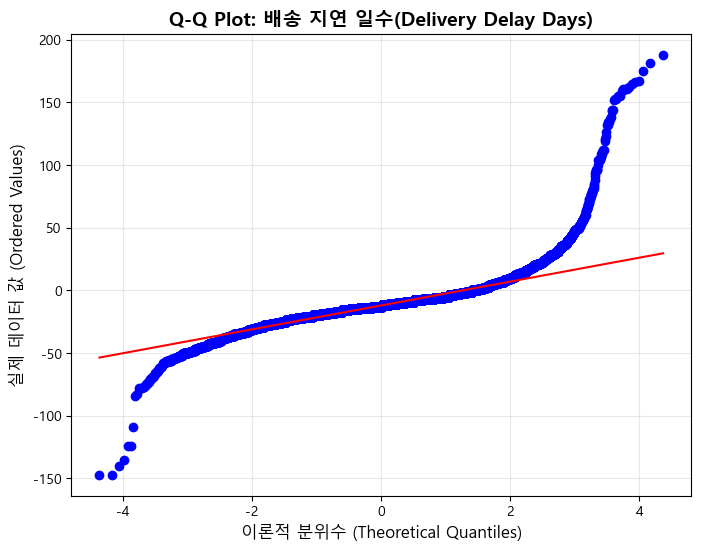


 [Shapiro-Wilk 정규성 검정 결과]
- 검정 통계량(W): 0.8781
- p-value: 7.997e-120
결론: 유의수준 0.05 하에서 정규분포를 따르지 않는다 (정규성 가정 위배)


In [506]:
# 정규성 

# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(df_product_filtered['delivery_delay_days'], dist="norm", plot=plt)

plt.title('Q-Q Plot: 배송 지연 일수(Delivery Delay Days)', fontsize=14, fontweight='bold')
plt.xlabel('이론적 분위수 (Theoretical Quantiles)', fontsize=12)
plt.ylabel('실제 데이터 값 (Ordered Values)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# Shapiro-Wilk 검정
stat_shapiro, p_shapiro = stats.shapiro(df_product_filtered['delivery_delay_days'])

print("\n [Shapiro-Wilk 정규성 검정 결과]")
print(f"- 검정 통계량(W): {stat_shapiro:.4f}")
print(f"- p-value: {p_shapiro:.3e}")

if p_shapiro < 0.05:
    print("결론: 유의수준 0.05 하에서 정규분포를 따르지 않는다 (정규성 가정 위배)")
else:
    print("결론: 유의수준 0.05 하에서 정규분포를 따른다 (정규성 가정 만족)")

- Q-Q plot : Heavy-tailed(무거운 꼬리) => 극단값 많음
- 정규성 위배

### 효과크기 구해야함

In [507]:
#Kruskal-Wallis 검정

groups = [group['delivery_delay_days'].values for name, group in df_product_filtered.groupby('product_category_name_english')]
h_stat, p_kruskal = stats.kruskal(*groups)

print("[Kruskal-Wallis 검정 결과]")
print(f"- 통계량(H): {h_stat:.4f}")
print(f"- p-value: {p_kruskal:.3e}\n")

if p_kruskal < 0.05:
    print("귀무가설 기각")
    print("결론: 카테고리에 따라 배송 지연 일수에 통계적으로 유의미한 차이가 있다")
else:
    print("귀무가설 기각실패")
    print("결론: 카테고리에 따라 배송 지연 일수에 통계적으로 유의미한 차이가 있지않다.")


# 전체 데이터 개수(n) 구하기
n = len(df_product_filtered)
k = len(groups)

# 효과크기 계산
epsilon_sq_1 = (h_stat - k + 1) / (n - k) # Tomczak & Tomczak(2014) 기준
epsilon_sq_2 = h_stat / (n - 1) # 일부 다른 문헌 기준

print(f"효과크기(Epsilon-squared): {epsilon_sq_1:.5f}(Tomczak & Tomczak(2014) 기준)")
print(f"효과크기(Epsilon-squared): {epsilon_sq_2:.5f}(일부 다른 문헌 기준)")

print("\n[효과크기 해석]")
if epsilon_sq_1 < 0.01:
    print("무시할 수 있는 수준의 차이")
elif epsilon_sq_1 < 0.04:
    print("작은 차이 (Small Effect)")
elif epsilon_sq_1 < 0.16:
    print("중간 정도의 차이 (Medium Effect)")
else:
    print("매우 큰 차이 (Large Effect)")

if epsilon_sq_2 < 0.01:
    print("무시할 수 있는 수준의 차이")
elif epsilon_sq_2 < 0.04:
    print("작은 차이 (Small Effect)")
elif epsilon_sq_2 < 0.16:
    print("중간 정도의 차이 (Medium Effect)")
else:
    print("매우 큰 차이 (Large Effect)")

[Kruskal-Wallis 검정 결과]
- 통계량(H): 446.7556
- p-value: 2.414e-58

귀무가설 기각
결론: 카테고리에 따라 배송 지연 일수에 통계적으로 유의미한 차이가 있다
효과크기(Epsilon-squared): 0.00349(Tomczak & Tomczak(2014) 기준)
효과크기(Epsilon-squared): 0.00408(일부 다른 문헌 기준)

[효과크기 해석]
무시할 수 있는 수준의 차이
무시할 수 있는 수준의 차이


In [508]:
# 사후검정(Dunn검정)

dunn_matrix = sp.posthoc_dunn(
    df_product_filtered, 
    val_col='delivery_delay_days', 
    group_col='product_category_name_english', 
    p_adjust='bonferroni' #fdr_bh : 상대적으로 유한 조정값
)

# 결과가 너무 많아서 p < 0.05 짝꿍들만 필터링

# 표(리스트) 형태로 펼치기.
dunn_unstacked = dunn_matrix.unstack().reset_index()
dunn_unstacked.columns = ['Category_1', 'Category_2', 'p_value']

# 자기 자신과의 비교 제거, p < 0.05 인 것만 남기기
significant_pairs = dunn_unstacked[
    (dunn_unstacked['Category_1'] != dunn_unstacked['Category_2']) & 
    (dunn_unstacked['p_value'] < 0.05)
]

# 중복된 짝(A-B, B-A) 제거를 위한 정렬
significant_pairs['pair'] = significant_pairs.apply(
    lambda x: tuple(sorted([x['Category_1'], x['Category_2']])), axis=1
)
significant_pairs = significant_pairs.drop_duplicates(subset=['pair']).drop(columns=['pair'])


# 결과 정렬 및 출력
significant_pairs = significant_pairs.sort_values('p_value')
significant_pairs

,Category_1,Category_2,p_value
1778,fashion_bags_accessories,telephony,2.902976e-14
1748,fashion_bags_accessories,food,4.347868e-14
1610,electronics,fashion_bags_accessories,3.280006e-13
2169,food,small_appliances,9.237033e-13
920,computers_accessories,telephony,2.140259e-12
...,...,...,...
1633,electronics,market_place,4.207278e-02
243,audio,housewares,4.219803e-02
1885,fashion_shoes,furniture_mattress_and_upholstery,4.233144e-02
956,consoles_games,food,4.508283e-02


### 인사이트 : Dunn 검정을 통해 통계적으로 유의한 쌍을 찾았으나, 앞선 효과크기의 결과대로 실질적 차이는 무의미하여 카테고리는 주요 변수에서 제외한다.

# 카이제곱 독립성 검정

In [509]:
display(df_product.head())
display(df_product_filtered.head())

,product_id,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_delay_days,is_delayed,actual_delay_days,product_volume_cm3
0,87285b34884572647811a353c7ac498a,housewares,500.0,19.0,8.0,13.0,-8,0,0,1976.0
1,595fac2a385ac33a80bd5114aec74eb8,perfumery,400.0,19.0,13.0,19.0,-6,0,0,4693.0
2,aa4383b373c6aca5d8797843e5594415,auto,420.0,24.0,19.0,21.0,-18,0,0,9576.0
3,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,450.0,30.0,10.0,20.0,-13,0,0,6000.0
4,65266b2da20d04dbe00c5c2d3bb7859e,stationery,250.0,51.0,15.0,15.0,-10,0,0,11475.0


,product_id,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_delay_days,is_delayed,actual_delay_days,product_volume_cm3
0,87285b34884572647811a353c7ac498a,housewares,500.0,19.0,8.0,13.0,-8,0,0,1976.0
1,595fac2a385ac33a80bd5114aec74eb8,perfumery,400.0,19.0,13.0,19.0,-6,0,0,4693.0
2,aa4383b373c6aca5d8797843e5594415,auto,420.0,24.0,19.0,21.0,-18,0,0,9576.0
3,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,450.0,30.0,10.0,20.0,-13,0,0,6000.0
4,65266b2da20d04dbe00c5c2d3bb7859e,stationery,250.0,51.0,15.0,15.0,-10,0,0,11475.0


## 가설설정(카테고리)
### 귀무가설
- "상품 카테고리와 배송지연여부는 서로 독립적이다."
- -> 상품의 카테고리에 따라 배송 지연 발생 비율에 차이가 나지 않는다.

### 대립가설
- "상품 카테고리와 배송지연여부는 서로 연관성이 있다(독립적이지 않다.)"
- -> 상품의 카테고리에 따라 배송 지연 발생 비율에 차이가 난다.(즉, 특정 카테고리가 배송 지연이 더 자주 발생하거나 덜 발생한다.)

In [510]:
df_product_filtered['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table                             10903
health_beauty                               9405
sports_leisure                              8395
furniture_decor                             8111
computers_accessories                       7613
housewares                                  6731
watches_gifts                               5821
telephony                                   4408
garden_tools                                4255
auto                                        4122
toys                                        4009
cool_stuff                                  3704
perfumery                                   3317
baby                                        2964
electronics                                 2715
stationery                                  2457
fashion_bags_accessories                    1978
pet_shop                                    1911
office_furniture                            1661
unknown                                

In [515]:
# 카이제곱 검정
ct = pd.crosstab(
    df_product['product_category_name_english'],
    df_product['is_delayed']
)

chi2, p, dof, expected = chi2_contingency(ct)

print("[카이제곱 검정 결과]")
print(f" 카이제곱: {chi2:.4f}, p-value: {p:.3e}, 자유도: {dof}")

# 효과크기: Cramer's V
n = ct.values.sum()
min_dim = min(ct.shape) - 1 # min(r-1, c-1)이랑 동일함. 
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"\n[효과크기 - Cramer's V]")
print(f"- V = {cramers_v:.4f}")

if cramers_v < 0.1:
    print("- 해석: 효과 없음")
elif cramers_v < 0.3:
    print("- 해석: 작은 효과")
elif cramers_v < 0.5:
    print("- 해석: 중간 효과")
else:
    print("- 해석: 큰 효과")

# 사후분석: 표준화 잔차
from statsmodels.stats.contingency_tables import Table

table = Table(ct)

std_resid_df = pd.DataFrame(
    table.standardized_resids.values, 
    index=ct.index, 
    columns=['정상(0)', '지연(1)']
)

k = len(ct)
z_threshold = 1.96 # 미보정 기준
#본페로니 보정으로 진행해본 결과 출력값이 너무 적어서 미보정으로 행

# 유의한 카테고리만 필터링
print(f"\n[표준화 잔차] (|z| > 1.96 → p<0.05, |z| > 2.58 → p<0.01)")

print("- z_threshold 사용")
sig_mask = std_resid_df['지연(1)'].abs() > z_threshold
sig_resid = std_resid_df[sig_mask].sort_values('지연(1)', ascending=False)
print(sig_resid.round(3))

[카이제곱 검정 결과]
 카이제곱: 187.5526, p-value: 1.842e-12, 자유도: 71

[효과크기 - Cramer's V]
- V = 0.0414
- 해석: 효과 없음

[표준화 잔차] (|z| > 1.96 → p<0.05, |z| > 2.58 → p<0.01)
- z_threshold 사용
                               정상(0)  지연(1)
product_category_name_english              
health_beauty                 -3.997  3.997
audio                         -3.836  3.836
baby                          -2.375  2.375
home_confort                  -2.348  2.348
office_furniture              -2.287  2.287
electronics                   -2.126  2.126
watches_gifts                 -1.978  1.978
construction_tools_safety      2.076 -2.076
market_place                   2.097 -2.097
small_appliances               2.257 -2.257
home_appliances                2.317 -2.317
fashion_bags_accessories       2.371 -2.371
pet_shop                       2.928 -2.928
luggage_accessories            3.345 -3.345
housewares                     5.350 -5.350


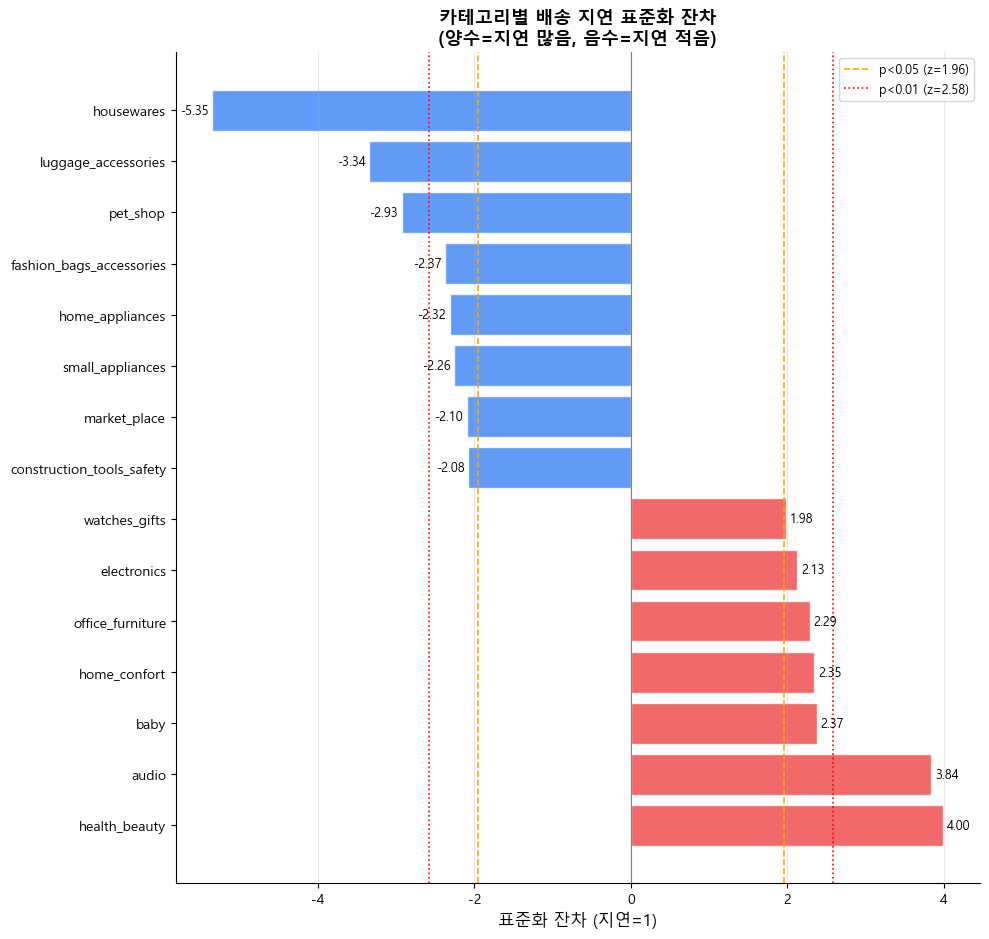

In [516]:
# ── 4. 시각화 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, len(sig_resid) * 0.5 + 2))

colors = ['#EF4444' if v > 0 else '#3B82F6' for v in sig_resid['지연(1)']]

bars = ax.barh(
    sig_resid.index,
    sig_resid['지연(1)'],
    color=colors,
    alpha=0.8,
    edgecolor='white'
)

# 기준선
ax.axvline(1.96,  color='orange', linestyle='--', linewidth=1.2, label='p<0.05 (z=1.96)')
ax.axvline(-1.96, color='orange', linestyle='--', linewidth=1.2)
ax.axvline(2.58,  color='red',    linestyle=':',  linewidth=1.2, label='p<0.01 (z=2.58)')
ax.axvline(-2.58, color='red',    linestyle=':',  linewidth=1.2)
ax.axvline(0,     color='gray',   linewidth=0.8)

# 값 표시
for bar, val in zip(bars, sig_resid['지연(1)']):
    ax.text(
        val + (0.05 if val > 0 else -0.05),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        ha='left' if val > 0 else 'right',
        fontsize=9
    )

ax.set_xlabel('표준화 잔차 (지연=1)', fontsize=12)
ax.set_title('카테고리별 배송 지연 표준화 잔차\n(양수=지연 많음, 음수=지연 적음)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [513]:
 # 전체 평균 지연율                                                                                                                                         
overall_rate = df_product['is_delayed'].mean()

delay_rate = (
    df_product.groupby('product_category_name_english')['is_delayed']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': '지연건수', 'count': '전체건수', 'mean': '지연율'})
)
delay_rate['지연율(%)'] = (delay_rate['지연율'] * 100).round(1)
delay_rate['전체평균대비'] = (delay_rate['지연율'] - overall_rate).round(3)
print(f"전체 평균 지연율: {overall_rate*100:.1f}%\n")
print(delay_rate.sort_values('지연율(%)', ascending=False))

전체 평균 지연율: 6.6%

                                         지연건수   전체건수       지연율  지연율(%)  전체평균대비
product_category_name_english                                                 
furniture_mattress_and_upholstery           5     37  0.135135    13.5   0.069
home_comfort_2                              4     30  0.133333    13.3   0.067
audio                                      42    361  0.116343    11.6   0.050
christmas_supplies                         15    150  0.100000    10.0   0.034
home_confort                               40    423  0.094563     9.5   0.028
fashion_underwear_beach                    12    127  0.094488     9.4   0.028
books_technical                            21    258  0.081395     8.1   0.015
office_furniture                          133   1661  0.080072     8.0   0.014
baby                                      228   2964  0.076923     7.7   0.011
electronics                               207   2715  0.076243     7.6   0.010
health_beauty                      

- healty_beauty : 실제 지연율(7.6%)인데, 표준화 잔차가 가장 높다.
- =>전체 주문 건수가 많아서 실제 물류 센터에 가해지는 체감 지연 건수가 높은 카테고리
- audio : 실제 지연율(11.6%)로 전체 평균의 거의 2배이며, 표준화 잔차가 다음으로 가장 높다.
- =>주문건수는 적어도 지연 발생확률이 높다.

## 최종 인사이트:
- 카테고리 변수는 전반적인 지연 예측 모델의 핵심 변수로 쓰기엔 영향력(Cramer's V)이 부족하다.
- 사후 분석을 통해서 'healty_beauty'와 'audio' 변수의 특이점을 발견했다.